In [7]:
!pip install --root-user-action=ignore opencv-python

Looking in indexes: https://mirror.kakao.com/pypi/simple


In [1]:
pip install libgl

Looking in indexes: https://mirror.kakao.com/pypi/simple
ERROR: Could not find a version that satisfies the requirement libgl (from versions: none)
ERROR: No matching distribution found for libgl
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install opencv-python-headless

Looking in indexes: https://mirror.kakao.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 2.0 MB/s  0:00:27m0:00:0100:01


In [2]:
# pip install matplotlib

In [3]:
### CUB_200_2011 데이터를 서버에 로드하고 설정후 분할을 위한 데이터 로더를 완성하시오

In [17]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, datasets, utils, models
import pathlib
from glob import glob
import os, time
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt

# 상수 정의
NUM_WORKERS = 4
DATA_ROOT = './data'
SPLIT = 'CUB'
BATCH_SIZE = 16
EPOCHS = 5
LR = 5e-3 # 초반엔 작게 주는 게 좋음
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

IMG_SIZE = 512
N_CLASSES = 201
IGNORE_INDEX = 255

OUT_DIR = 'runs/Unet_scratch'
BEST_PATH = os.path.join(OUT_DIR, 'best_Unet_cub200.pth')
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
# 데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img, mask):
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1) < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask
    return _tfm

class CubDatasetTrain(Dataset):
    def __init__(self, root, split, image_set, transforms=None):
        base = Path(root)/split
        self.img_dir = base/'CUB_200_2011/images'
        self.mask_dir = base/'CUB_200_2011/segmentations'
        with open(base/'cvpr2016_cub'/'Segmentation'/f'{image_set}ids.txt') as f:
            self.ids = [x for x in f if x.strip()]
        self.tfm = transforms
        
    def __len__(self):
        return len(self.ids)
        
    def __getitem__(self, index):
        id_ = self.ids[index]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask

class CubDatasetVal(CubDatasetTrain):
    def __getitem__(self, idx):
        id_ = self.ids[idx]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}classes.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask, id_

def get_loader():
    tr_ds = CubDatasetTrain(DATA_ROOT, SPLIT, 'train', transforms=make_transform(train=True))
    val_ds = CubDatasetVal(DATA_ROOT, SPLIT, 'val', transforms=make_transform(train=False))
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # pin메모리는 GPU를 사용하는 것임
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader

In [19]:
# 강사님 코드

In [20]:
import os
from pathlib import Path
from PIL import Image

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

In [23]:
glob(basepath+'/*')

['./data/CUB/CUB_200_2011/attributes',
 './data/CUB/CUB_200_2011/parts',
 './data/CUB/CUB_200_2011/image_class_labels.txt',
 './data/CUB/CUB_200_2011/images.txt',
 './data/CUB/CUB_200_2011/classes.txt',
 './data/CUB/CUB_200_2011/images',
 './data/CUB/CUB_200_2011/VOCdevkit',
 './data/CUB/CUB_200_2011/segmentations',
 './data/CUB/CUB_200_2011/README',
 './data/CUB/CUB_200_2011/bounding_boxes.txt',
 './data/CUB/CUB_200_2011/data',
 './data/CUB/CUB_200_2011/train_test_split.txt']

In [55]:
basepath = './data/CUB/CUB_200_2011'

def make_transform(train):
    def _tfm(img, mask):
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1) < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask
    return _tfm
    
class CUBBinarySg(Dataset):
    def __init__(self, root, img_id, id2path, tf=None):
        self.root = Path(root)
        self.ids = img_id
        self.id2path = id2path
        self.tf = tf
        self.img_dir = self.root/'images'
        self.seg_dir = self.root/'segmentations'

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_idx = self.ids[idx]
        img_path = self.id2path[img_idx]
        img_path_call = self.img_dir/img_path
        img = Image.open(img_path_call).convert('RGB')
        
        sg_path_call = (self.seg_dir/img_path).with_suffix('.png') # 마스크는 주로 png임. png파일만 가져옴
        mask = Image.open(sg_path_call)
        mask_np = np.array(mask)
        mask_np = (mask_np>0).astype(np.uint8)
        mask = Image.fromarray(mask_np)

        if self.tf:
            img, mask = self.tf(img, mask)
        return img, mask

def read_id_to_path(root):
    id2path = {}
    with open(os.path.join(root, 'images.txt'), 'r') as f:
        for i in f:
            idx, p = i.strip().split()
            id2path[int(idx)] = p
    return id2path

def read_tr_test_split(root):
    split = {}
    with open(os.path.join(root, 'train_test_split.txt'), 'r') as f:
        for i in f:
            idx, is_train = i.strip().split()
            split[int(idx)] = is_train
    return split

def get_loaders():
    root = basepath
    ck_l = [
        os.path.join(root, 'images.txt'),
        os.path.join(root, 'train_test_split.txt'),
        os.path.join(root, 'images')
    ]
    for i in ck_l:
        if not (os.path.exists(i) and (os.path.isdir(i) or os.path.isfile(i))):
            raise FileNotFoundError(f"{i} 파일이 없습니다.")

    id2path = read_id_to_path(root)
    split = read_tr_test_split(root)
    
    tr_ids = [int(i) for i, t in split.items() if t == '1']
    val_ids = [int(i) for i, t in split.items() if t == '0']
    
    tr_ds = CUBBinarySg(root, tr_ids, id2path, tf=make_transform(True))
    val_ds = CUBBinarySg(root, val_ids, id2path, tf=make_transform(False))
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader
tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loaders()

In [89]:
import matplotlib.pyplot as plt
BG_COLOR = np.array([50,50,50], dtype=np.uint8)
BIRD_COLOR = np.array([200,50,50], dtype=np.uint8)
IGNORE_COLOR = np.array([100,100,100], dtype=np.uint8)

def _denorm(img):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device)[:,None,None]
    std = torch.tensor([0.229, 0.224, 0.225], device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)

def _colorize_binary(mask_np, ignore_idx=255):
    out = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    out[mask_np == 0] = BG_COLOR
    out[mask_np == 1] = BIRD_COLOR
    out[mask_np == ignore_idx] = IGNORE_COLOR
    return out

def overlay_mask(img_np, mask_rgb, alpha=0.5):
    base = (img_np * 255).astype(np.uint8)
    over = (alpha * mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds, indices=None, n=6, alpha=0.5, ignore_idx=255):
    if indices is None:
        import random
        n = min(n, len(ds))
        indices = random.sample(range(len(ds)), k=n)
    else:
        n = len(indices)
    r, c = n, 3
    plt.figure(figsize=(c*4, r*3.5))

    for i, idx in enumerate(indices):
        sample = ds[idx]
        if len(sample) == 3:
            img, mask, id_ = sample
        else:
            img, mask = sample
        # B = img.size(0)
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb = _colorize_binary(mask_np, ignore_idx)
        over = overlay_mask(img_np, mask_rgb, alpha)

        base = i*3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')

        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('over')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_6770/2860790594.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_np = np.array(mask)


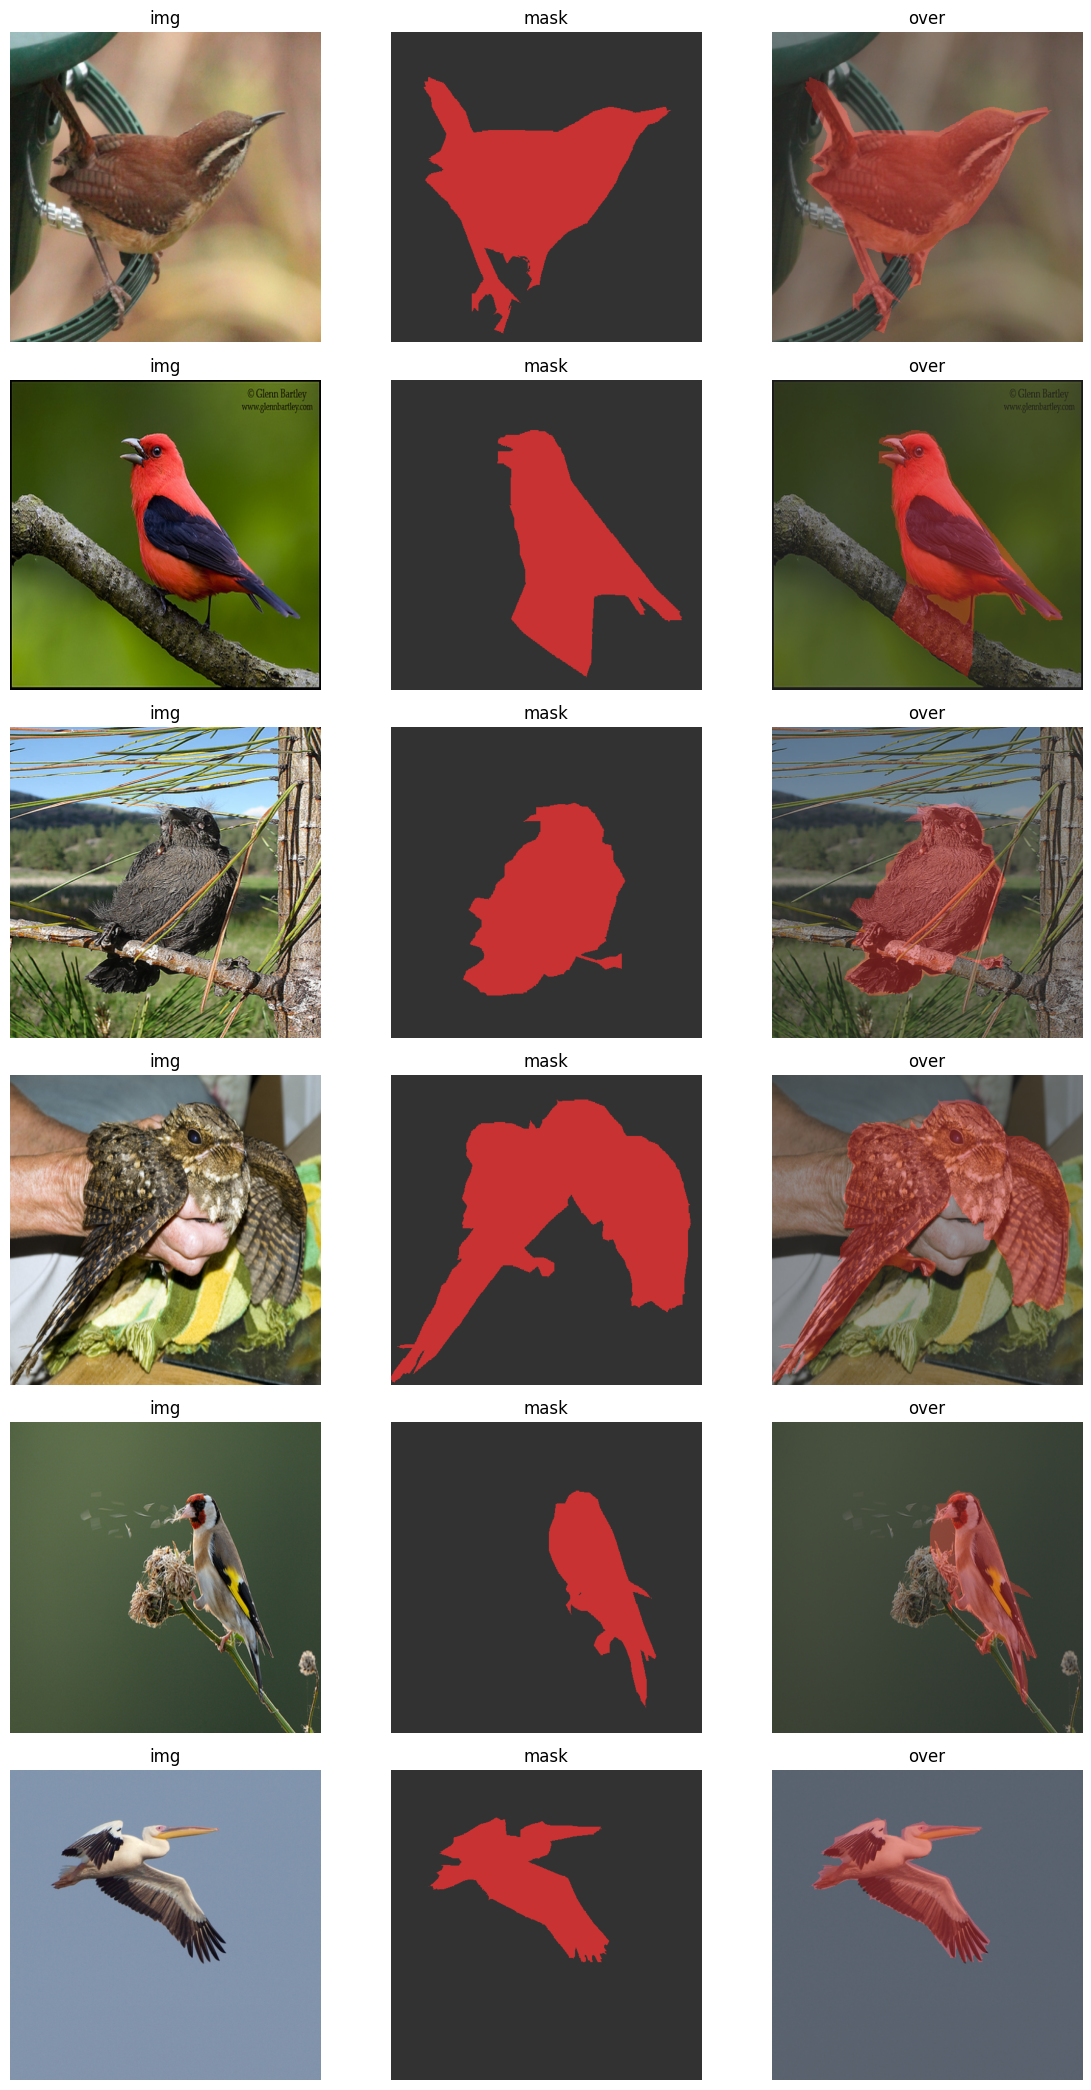

In [90]:
show_img_mask(tr_ds, n=6)

In [51]:
img=Image.open('data/CUB/CUB_200_2011/segmentations/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.png')

In [38]:
np.unique(img) # 원래는 하나의 클래스만 존재해야 하지만 0과 255를 제외하면 4개의 클래스를 갖고 있는 걸로 보임

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [39]:
np.unique(img.convert('L')) # L은 이진화 처리라고 함

array([  0,  51, 102, 153, 204, 255], dtype=uint8)